# Final few shot

Combined notebook for **BLIP2** and **Qwen2-VL** few-shot disaster classification on BanglaCalamityMMD.

Includes:
- full 790 test-sample evaluation
- K=4 few-shot prompting
- semantic candidate parser/guardrail
- validation tuning for semantic parser
- BLIP2 confidence threshold tuning
- classification report and colorful confusion matrix

No fine-tuning is performed. No model weights are updated. The labelled examples are inserted into the prompt.

In [ ]:
# Safe Colab install. Do not upgrade numpy/pandas/pillow/scikit-learn.
!pip -q install transformers accelerate bitsandbytes qwen-vl-utils tqdm matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 16.1 MB/s eta 0:00:00


In [ ]:
import os, re, gc, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

CUDA available: True
GPU: Tesla T4
numpy: 2.0.2
pandas: 2.2.2


## 1. Mount Drive and locate dataset

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/AI_Project/BanglaCalamityMMD"

TRAIN_CSV = os.path.join(DATASET_ROOT, "Disaster_train.csv")
VAL_CSV   = os.path.join(DATASET_ROOT, "Disaster_validation.csv")
TEST_CSV  = os.path.join(DATASET_ROOT, "Disaster_test.csv")

TRAIN_IMG_DIR = os.path.join(DATASET_ROOT, "Train")
VAL_IMG_DIR   = os.path.join(DATASET_ROOT, "Validation")
TEST_IMG_DIR  = os.path.join(DATASET_ROOT, "Test")

RESULT_DIR = os.path.join(DATASET_ROOT, "final_few_shot_results")
os.makedirs(RESULT_DIR, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR, os.path.exists(TRAIN_IMG_DIR))
print("VAL_IMG_DIR:", VAL_IMG_DIR, os.path.exists(VAL_IMG_DIR))
print("TEST_IMG_DIR:", TEST_IMG_DIR, os.path.exists(TEST_IMG_DIR))
print("RESULT_DIR:", RESULT_DIR)

DATASET_ROOT: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD
TRAIN_IMG_DIR: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/Train True
VAL_IMG_DIR: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/Validation True
TEST_IMG_DIR: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/Test True
RESULT_DIR: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/final_few_shot_results


## 2. Labels, text cleaning and dataset loading

In [ ]:
CLASSES = ["Earthquake", "Flood", "Landslides", "Wildfire", "Tropical Storm", "Drought", "Human Damage", "Non Disaster"]

LABEL_FIX = {
    "earthquake":"Earthquake", "earthquakes":"Earthquake", "earth quake":"Earthquake", "quake":"Earthquake", "ভূমিকম্প":"Earthquake",
    "flood":"Flood", "floods":"Flood", "flooding":"Flood", "flash flood":"Flood", "বন্যা":"Flood", "প্লাবন":"Flood", "জলাবদ্ধতা":"Flood",
    "landslide":"Landslides", "landslides":"Landslides", "land slide":"Landslides", "land slides":"Landslides", "mudslide":"Landslides", "ভূমিধস":"Landslides", "ভূমিস্খলন":"Landslides", "পাহাড় ধস":"Landslides",
    "wildfire":"Wildfire", "wildfires":"Wildfire", "wild fire":"Wildfire", "forest fire":"Wildfire", "bushfire":"Wildfire", "বন আগুন":"Wildfire", "বনে আগুন":"Wildfire", "দাবানল":"Wildfire",
    "tropical storm":"Tropical Storm", "tropical storms":"Tropical Storm", "storm":"Tropical Storm", "cyclone":"Tropical Storm", "hurricane":"Tropical Storm", "typhoon":"Tropical Storm", "ঘূর্ণিঝড়":"Tropical Storm", "ঘূর্ণিঝড়":"Tropical Storm", "ঝড়":"Tropical Storm", "ঝড়":"Tropical Storm", "সাইক্লোন":"Tropical Storm",
    "drought":"Drought", "droughts":"Drought", "dry season":"Drought", "water shortage":"Drought", "খরা":"Drought", "অনাবৃষ্টি":"Drought", "পানির সংকট":"Drought",
    "human damage":"Human Damage", "human damages":"Human Damage", "human caused damage":"Human Damage", "man made disaster":"Human Damage", "human made disaster":"Human Damage", "accident":"Human Damage", "explosion":"Human Damage", "collapse":"Human Damage", "building collapse":"Human Damage", "fire accident":"Human Damage", "মানবসৃষ্ট ক্ষয়ক্ষতি":"Human Damage", "মানবসৃষ্ট ক্ষতি":"Human Damage", "মানবসৃষ্ট দুর্যোগ":"Human Damage", "দুর্ঘটনা":"Human Damage", "বিস্ফোরণ":"Human Damage", "ভবন ধস":"Human Damage",
    "non disaster":"Non Disaster", "non-disaster":"Non Disaster", "non_disaster":"Non Disaster", "nondisaster":"Non Disaster", "not disaster":"Non Disaster", "no disaster":"Non Disaster", "normal":"Non Disaster", "safe":"Non Disaster", "দুর্যোগ নয়":"Non Disaster", "কোনো দুর্যোগ নয়":"Non Disaster", "দুর্যোগ না":"Non Disaster", "স্বাভাবিক":"Non Disaster"
}

BANGLA_LABELS = {
    "Earthquake":"ভূমিকম্প", "Flood":"বন্যা", "Landslides":"ভূমিধস", "Wildfire":"দাবানল",
    "Tropical Storm":"ঘূর্ণিঝড়", "Drought":"খরা", "Human Damage":"মানবসৃষ্ট ক্ষয়ক্ষতি", "Non Disaster":"দুর্যোগ নয়"
}

def normalize_label(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    key = x.lower().replace("_", " ").replace("-", " ")
    key = re.sub(r"\s+", " ", key).strip()
    return LABEL_FIX.get(key, LABEL_FIX.get(x, x))

def fix_mojibake_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    if "à¦" in x or "à§" in x:
        try:
            return x.encode("latin1").decode("utf-8")
        except Exception:
            return x
    return x

def clean_text(x):
    x = fix_mojibake_text(x)
    x = x.replace("\n", " ").replace("\t", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def get_image_path(image_id, image_dir):
    image_id = str(image_id).strip()
    base = os.path.join(image_dir, image_id)
    for ext in [".jpg", ".jpeg", ".png", ".webp", ".JPG", ".JPEG", ".PNG", ""]:
        p = base + ext
        if os.path.exists(p):
            return p
    return base

def load_split(csv_path, image_dir):
    df = pd.read_csv(csv_path)
    df["context"] = df["context"].apply(clean_text)
    df["category"] = df["category"].apply(normalize_label)

    bad = sorted(set(df["category"]) - set(CLASSES))
    if bad:
        print("Unknown labels:", bad)
        raise ValueError("Some labels are not mapped.")

    df["image_path"] = df["image_id"].apply(lambda x: get_image_path(x, image_dir))

    print("\n", os.path.basename(csv_path))
    print("Rows:", len(df))
    print("Missing images:", (~df["image_path"].apply(os.path.exists)).sum())
    print(df["category"].value_counts())

    return df

train_df = load_split(TRAIN_CSV, TRAIN_IMG_DIR)
val_df = load_split(VAL_CSV, VAL_IMG_DIR)
test_df = load_split(TEST_CSV, TEST_IMG_DIR)
display(train_df.head())


 Disaster_train.csv
Rows: 6323
Missing images: 0
category
Landslides        803
Tropical Storm    800
Drought           800
Flood             800
Non Disaster      800
Earthquake        800
Human Damage      800
Wildfire          720
Name: count, dtype: int64

 Disaster_validation.csv
Rows: 790
Missing images: 0
category
Landslides        100
Tropical Storm    100
Drought           100
Flood             100
Non Disaster      100
Earthquake        100
Human Damage      100
Wildfire           90
Name: count, dtype: int64

 Disaster_test.csv
Rows: 790
Missing images: 0
category
Landslides        100
Tropical Storm    100
Drought           100
Flood             100
Non Disaster      100
Earthquake        100
Human Damage      100
Wildfire           90
Name: count, dtype: int64


,image_id,context,category,image_path
0,landslides_1,ভারী বৃষ্টিপাতের কারণে ভূমিধসের সূত্রপাত হয়েছ...,Landslides,/content/drive/MyDrive/AI_Project/BanglaCalami...
1,landslides_2,প্রবল বৃষ্টির মধ্যে ইতালির ইসচিয়া দ্বীপে একটি...,Landslides,/content/drive/MyDrive/AI_Project/BanglaCalami...
2,landslides_3,সোমবার একটি পাহাড়ের পাশে একটি বিশাল ভূমিধসের ...,Landslides,/content/drive/MyDrive/AI_Project/BanglaCalami...
3,landslides_4,স্থানীয় ভিয়েতনাম সংবাদ সংস্থার সংবাদদাতা অনু...,Landslides,/content/drive/MyDrive/AI_Project/BanglaCalami...
4,landslides_5,"জাকার্তা, ২৬ মার্চ (ইউএনআই) ইন্দোনেশিয়ার পশ্চ...",Landslides,/content/drive/MyDrive/AI_Project/BanglaCalami...


## 3. Common helpers

In [ ]:
def load_and_resize_image(path, max_side=336):
    try:
        image = Image.open(path).convert("RGB")
        w, h = image.size
        scale = max(w, h) / max_side
        if scale > 1:
            image = image.resize((int(w / scale), int(h / scale)), Image.LANCZOS)
        return image
    except Exception as e:
        print("Image load error:", path, e)
        return None

def evaluate_results(results_df, model_name):
    y_true = results_df["Ground_Truth"].tolist()
    y_pred = results_df["Prediction"].tolist()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print("\n" + "=" * 90)
    print(model_name)
    print("=" * 90)
    print(f"Total samples    : {len(results_df)}")
    print(f"Accuracy         : {acc * 100:.2f}%")
    print(f"Macro Precision  : {prec * 100:.2f}%")
    print(f"Macro Recall     : {rec * 100:.2f}%")
    print(f"Macro F1         : {f1 * 100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=CLASSES, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)

    print("\nConfusion Matrix:")
    display(cm_df)

    plt.figure(figsize=(11, 8.5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.7, linecolor="white", cbar=True, square=True, annot_kws={"size": 10, "weight": "bold"})
    plt.title(model_name + " - Confusion Matrix", fontsize=15, weight="bold", pad=16)
    plt.ylabel("Actual Label", fontsize=12, weight="bold")
    plt.xlabel("Predicted Label", fontsize=12, weight="bold")
    plt.xticks(rotation=35, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("/", "_").replace(":", "_").replace("|", "_")
    fig_path = os.path.join(RESULT_DIR, f"{safe_name}_confusion_matrix.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved colorful confusion matrix:", fig_path)
    plt.show()

    print("\nPrediction distribution:")
    print(results_df["Prediction"].value_counts())

    return {"model": model_name, "samples": len(results_df), "accuracy": acc, "macro_precision": prec, "macro_recall": rec, "macro_f1": f1}

## 4. Shared semantic parser

In [ ]:
DISASTER_KEYWORDS = {
    "Earthquake": {"bn": ["ভূমিকম্প", "কম্পন", "মাটি কাঁপ", "ধসে পড়", "ধসে পড়ে", "ভবন ধস", "ভূকম্প", "রিখটার", "সিসমিক"], "en": ["earthquake", "quake", "tremor", "seismic", "richter"]},
    "Flood": {"bn": ["বন্যা", "প্লাবন", "জলাবদ্ধ", "পানি বৃদ্ধি", "নদীর পানি", "ডুবে", "তলিয়ে", "তলিয়ে", "ভারী বৃষ্টি", "অতিবৃষ্টি", "বন্যার পানি", "পানিবন্দি", "পানিতে ডুবে", "পানি ঢুকে"], "en": ["flood", "flooding", "waterlogging", "submerged", "heavy rain", "river overflow", "inundated"]},
    "Landslides": {"bn": ["ভূমিধস", "ভূমিস্খলন", "পাহাড় ধস", "পাহাড় ধস", "মাটি ধস", "কাদা ধস", "পাথর ধস", "ঢাল ধস", "ধস নেমে", "পাহাড়ি ধস", "পাহাড়ি ধস"], "en": ["landslide", "landslides", "mudslide", "rockfall", "hill collapse", "slope failure"]},
    "Wildfire": {"bn": ["দাবানল", "বন আগুন", "বনে আগুন", "অরণ্যে আগুন", "জঙ্গলে আগুন", "বনাঞ্চলে আগুন", "শুকনো ঘাসে আগুন", "বনের আগুন"], "en": ["wildfire", "wildfires", "forest fire", "bushfire", "vegetation fire"]},
    "Tropical Storm": {"bn": ["ঘূর্ণিঝড়", "ঘূর্ণিঝড়", "ঝড়", "ঝড়", "সাইক্লোন", "প্রবল বাতাস", "ঝোড়ো হাওয়া", "ঝোড়ো হাওয়া", "জলোচ্ছ্বাস", "নিম্নচাপ", "টাইফুন", "হারিকেন", "বাতাসের বেগ", "ঝড়ো বাতাস", "ঝড়ো বাতাস"], "en": ["tropical storm", "storm", "cyclone", "hurricane", "typhoon", "strong wind", "storm surge", "low pressure"]},
    "Drought": {"bn": ["খরা", "অনাবৃষ্টি", "বৃষ্টি নেই", "পানির সংকট", "জলসংকট", "শুকনো জমি", "ফসল নষ্ট", "তীব্র গরম", "পানি স্বল্পতা", "পানি সংকট", "শুষ্ক", "শুকিয়ে"], "en": ["drought", "dry spell", "water shortage", "lack of rain", "crop failure", "dry land"]},
    "Human Damage": {"bn": ["মানবসৃষ্ট", "দুর্ঘটনা", "বিস্ফোরণ", "ভবন ধস", "অগ্নিকাণ্ড", "আগুনের দুর্ঘটনা", "সংঘর্ষ", "হামলা", "কারখানা দুর্ঘটনা", "সড়ক দুর্ঘটনা", "সড়ক দুর্ঘটনা", "ট্রেন দুর্ঘটনা", "বিমান দুর্ঘটনা"], "en": ["human damage", "accident", "explosion", "collapse", "fire accident", "industrial accident", "road accident", "attack", "conflict", "building collapse"]},
    "Non Disaster": {"bn": ["দুর্যোগ নয়", "দুর্যোগ নয়", "স্বাভাবিক", "সাধারণ", "নিরাপদ", "কোনো ক্ষতি নেই", "সাধারণ ঘটনা", "শান্তিপূর্ণ", "উৎসব", "অনুষ্ঠান"], "en": ["non disaster", "non-disaster", "normal", "safe", "ordinary", "not disaster", "peaceful"]}
}

def keyword_score_context(text):
    text_clean = clean_text(text)
    text_lower = text_clean.lower()
    scores = {cls: 0.0 for cls in CLASSES}

    for cls, group in DISASTER_KEYWORDS.items():
        for kw in group["bn"]:
            if kw in text_clean:
                scores[cls] += 3.0
        for kw in group["en"]:
            if kw.lower() in text_lower:
                scores[cls] += 2.0
    return scores

In [ ]:
char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 6), max_features=150000, min_df=2, sublinear_tf=True)
word_vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 3), max_features=100000, min_df=2, sublinear_tf=True, token_pattern=r"(?u)\b\w+\b")

train_texts = train_df["context"].fillna("").astype(str).apply(clean_text).tolist()
val_texts = val_df["context"].fillna("").astype(str).apply(clean_text).tolist()
test_texts = test_df["context"].fillna("").astype(str).apply(clean_text).tolist()

print("Fitting semantic TF-IDF features...")

train_char = char_vectorizer.fit_transform(train_texts)
val_char = char_vectorizer.transform(val_texts)
test_char = char_vectorizer.transform(test_texts)

train_word = word_vectorizer.fit_transform(train_texts)
val_word = word_vectorizer.transform(val_texts)
test_word = word_vectorizer.transform(test_texts)

train_semantic_matrix = hstack([train_char, train_word]).tocsr()
val_semantic_matrix = hstack([val_char, val_word]).tocsr()
test_semantic_matrix = hstack([test_char, test_word]).tocsr()

print(train_semantic_matrix.shape, val_semantic_matrix.shape, test_semantic_matrix.shape)

Fitting semantic TF-IDF features...
(6323, 113245) (790, 113245) (790, 113245)


In [ ]:
class_centroids = {}

for cls in CLASSES:
    idxs = train_df.index[train_df["category"] == cls].tolist()
    cls_matrix = train_semantic_matrix[idxs]
    centroid = cls_matrix.mean(axis=0)
    class_centroids[cls] = np.asarray(centroid).ravel()

centroid_matrix = np.vstack([class_centroids[cls] for cls in CLASSES])
print("Centroid matrix:", centroid_matrix.shape)

Centroid matrix: (8, 113245)


In [ ]:
TOP_CANDIDATE_CLASSES = 4

def semantic_predict_with_params(text, text_vec, knn_k=25, w_knn=0.60, w_centroid=0.25, w_keyword=0.15, top_n=4):
    sims = cosine_similarity(text_vec, train_semantic_matrix)[0]
    top_indices = sims.argsort()[::-1][:knn_k]

    knn_scores = {cls: 0.0 for cls in CLASSES}
    for idx in top_indices:
        label = train_df.iloc[idx]["category"]
        knn_scores[label] += float(sims[idx])

    centroid_scores_raw = cosine_similarity(text_vec, centroid_matrix)[0]
    centroid_scores = {cls: float(centroid_scores_raw[i]) for i, cls in enumerate(CLASSES)}
    keyword_scores = keyword_score_context(text)

    final_scores = {}
    for cls in CLASSES:
        final_scores[cls] = w_knn * knn_scores[cls] + w_centroid * centroid_scores[cls] + w_keyword * keyword_scores[cls]

    ranked_classes = sorted(CLASSES, key=lambda x: final_scores[x], reverse=True)
    prediction = ranked_classes[0]
    candidates = ranked_classes[:top_n]

    confidence_gap = final_scores[ranked_classes[0]] - final_scores[ranked_classes[1]]
    return prediction, candidates, final_scores, confidence_gap

def get_candidate_fewshots(text_vec, candidate_classes, k=4):
    sims = cosine_similarity(text_vec, train_semantic_matrix)[0]
    selected_indices = []

    for cls in candidate_classes:
        cls_indices = train_df.index[train_df["category"] == cls].tolist()
        if len(cls_indices) == 0:
            continue
        best_idx = max(cls_indices, key=lambda i: sims[i])
        if best_idx not in selected_indices:
            selected_indices.append(best_idx)
        if len(selected_indices) >= k:
            break

    if len(selected_indices) < k:
        ranked_all = sims.argsort()[::-1]
        for idx in ranked_all:
            if idx not in selected_indices:
                selected_indices.append(idx)
            if len(selected_indices) >= k:
                break

    return train_df.loc[selected_indices].head(k)

def make_candidate_options(candidate_classes, seed_value):
    rng = random.Random(seed_value)
    labels = candidate_classes.copy()
    rng.shuffle(labels)

    letters = list("ABCDEFGH")[:len(labels)]
    letter_to_label, label_to_letter, lines = {}, {}, []

    for letter, label in zip(letters, labels):
        letter_to_label[letter] = label
        label_to_letter[label] = letter
        lines.append(f"{letter}. {label}")

    return "\n".join(lines), letter_to_label, label_to_letter

def parse_letter_output(raw_text, letter_to_label):
    if raw_text is None:
        return None

    text = str(raw_text).strip()
    text_upper = text.upper()

    for item in ["ANSWER:", "ANS:", "LABEL:", "PREDICTION:", "OPTION:", "FINAL:", "FINAL ANSWER:", ".", ")", ":", ",", ";", "\n", "\t"]:
        text_upper = text_upper.replace(item, " ")

    text_upper = re.sub(r"\s+", " ", text_upper).strip()

    if text_upper in letter_to_label:
        return letter_to_label[text_upper]

    for token in text_upper.split():
        if token in letter_to_label:
            return letter_to_label[token]

    text_lower = text.lower()
    for cls in CLASSES:
        if cls.lower() in text_lower:
            return cls

    return None

## 5. Tune semantic parser on validation set

In [ ]:
y_val = val_df["category"].tolist()
param_grid = []

for knn_k in [9, 15, 21, 25, 31, 41]:
    for w_knn, w_centroid, w_keyword in [
        (0.70, 0.20, 0.10),
        (0.65, 0.25, 0.10),
        (0.60, 0.25, 0.15),
        (0.55, 0.30, 0.15),
        (0.50, 0.30, 0.20),
        (0.45, 0.35, 0.20),
        (0.75, 0.15, 0.10),
    ]:
        param_grid.append({"knn_k": knn_k, "w_knn": w_knn, "w_centroid": w_centroid, "w_keyword": w_keyword})

best_params, best_val_f1, best_val_acc = None, -1, -1
tuning_rows = []

for params in param_grid:
    preds = []

    for i, text in enumerate(val_texts):
        pred, _, _, _ = semantic_predict_with_params(
            text=text,
            text_vec=val_semantic_matrix[i],
            knn_k=params["knn_k"],
            w_knn=params["w_knn"],
            w_centroid=params["w_centroid"],
            w_keyword=params["w_keyword"],
            top_n=TOP_CANDIDATE_CLASSES
        )
        preds.append(pred)

    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro", zero_division=0)
    tuning_rows.append({**params, "val_accuracy": acc, "val_macro_f1": f1})

    print(f"knn={params['knn_k']:<2} weights=({params['w_knn']}, {params['w_centroid']}, {params['w_keyword']}) Val Acc={acc*100:.2f}% | Macro F1={f1*100:.2f}%")

    if f1 > best_val_f1:
        best_val_f1, best_val_acc, best_params = f1, acc, params

tuning_df = pd.DataFrame(tuning_rows).sort_values(by="val_macro_f1", ascending=False)
display(tuning_df.head(10))

print("Best params:", best_params)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Best Validation Macro F1: {best_val_f1*100:.2f}%")

tuning_df.to_csv(os.path.join(RESULT_DIR, "semantic_parser_tuning_validation.csv"), index=False)

knn=9  weights=(0.7, 0.2, 0.1) Val Acc=90.13% | Macro F1=90.07%
knn=9  weights=(0.65, 0.25, 0.1) Val Acc=90.38% | Macro F1=90.33%
knn=9  weights=(0.6, 0.25, 0.15) Val Acc=92.03% | Macro F1=92.03%
knn=9  weights=(0.55, 0.3, 0.15) Val Acc=92.28% | Macro F1=92.28%
knn=9  weights=(0.5, 0.3, 0.2) Val Acc=93.42% | Macro F1=93.42%
knn=9  weights=(0.45, 0.35, 0.2) Val Acc=93.67% | Macro F1=93.67%
knn=9  weights=(0.75, 0.15, 0.1) Val Acc=89.87% | Macro F1=89.80%
knn=15 weights=(0.7, 0.2, 0.1) Val Acc=90.63% | Macro F1=90.56%
knn=15 weights=(0.65, 0.25, 0.1) Val Acc=90.76% | Macro F1=90.69%
knn=15 weights=(0.6, 0.25, 0.15) Val Acc=92.41% | Macro F1=92.38%
knn=15 weights=(0.55, 0.3, 0.15) Val Acc=92.66% | Macro F1=92.65%
knn=15 weights=(0.5, 0.3, 0.2) Val Acc=93.16% | Macro F1=93.17%
knn=15 weights=(0.45, 0.35, 0.2) Val Acc=93.54% | Macro F1=93.55%
knn=15 weights=(0.75, 0.15, 0.1) Val Acc=90.51% | Macro F1=90.42%
knn=21 weights=(0.7, 0.2, 0.1) Val Acc=90.38% | Macro F1=90.28%
knn=21 weights=(0.65

,knn_k,w_knn,w_centroid,w_keyword,val_accuracy,val_macro_f1
5,9,0.45,0.35,0.20,0.936709,0.936659
12,15,0.45,0.35,0.20,0.935443,0.935537
4,9,0.50,0.30,0.20,0.934177,0.934158
19,21,0.45,0.35,0.20,0.932911,0.932961
26,25,0.45,0.35,0.20,0.932911,0.932893
11,15,0.50,0.30,0.20,0.931646,0.931673
18,21,0.50,0.30,0.20,0.929114,0.929054
10,15,0.55,0.30,0.15,0.926582,0.926471
33,31,0.45,0.35,0.20,0.925316,0.925218
9,15,0.60,0.25,0.15,0.924051,0.923815


Best params: {'knn_k': 9, 'w_knn': 0.45, 'w_centroid': 0.35, 'w_keyword': 0.2}
Best Validation Accuracy: 93.67%
Best Validation Macro F1: 93.67%


## 6. BLIP2 K=4 few-shot

In [ ]:
RUN_BLIP2 = True
BLIP2_K_SHOTS = 4
BLIP2_MAX_TEXT_CHARS = 120
BLIP2_IMAGE_SIZE = 224

if RUN_BLIP2:
    from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

    torch.cuda.empty_cache()
    gc.collect()

    BLIP2_MODEL_ID = "Salesforce/blip2-opt-2.7b"
    blip_quant = BitsAndBytesConfig(load_in_8bit=True)

    blip_processor = Blip2Processor.from_pretrained(BLIP2_MODEL_ID)
    blip_model = Blip2ForConditionalGeneration.from_pretrained(
        BLIP2_MODEL_ID,
        quantization_config=blip_quant,
        device_map="auto",
        torch_dtype=torch.float16
    )
    blip_model.eval()
    print("BLIP2 loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP2 loaded.


In [ ]:
def build_blip2_prompt(fewshot_rows, test_context, option_text, label_to_letter):
    examples = []

    for i, (_, row) in enumerate(fewshot_rows.iterrows(), start=1):
        ctx = clean_text(row["context"])[:BLIP2_MAX_TEXT_CHARS]
        label = row["category"]
        if label not in label_to_letter:
            continue
        examples.append(f"Ex{i}: {ctx}\nAns: {label_to_letter[label]}\n")

    examples_text = "\n".join(examples)
    test_text = clean_text(test_context)[:BLIP2_MAX_TEXT_CHARS]

    prompt = f'''
Task: disaster classification.

Choose one option.

Options:
{option_text}

Examples:
{examples_text}

Test: {test_text}

Answer only one letter.

Ans:
'''.strip()

    return prompt[:950]

def blip2_predict(image_path, test_context, test_vec, sample_id, confidence_threshold):
    semantic_pred, candidates, _, confidence_gap = semantic_predict_with_params(
        text=test_context,
        text_vec=test_vec,
        knn_k=best_params["knn_k"],
        w_knn=best_params["w_knn"],
        w_centroid=best_params["w_centroid"],
        w_keyword=best_params["w_keyword"],
        top_n=TOP_CANDIDATE_CLASSES
    )

    fewshots = get_candidate_fewshots(test_vec, candidates, BLIP2_K_SHOTS)
    option_text, letter_to_label, label_to_letter = make_candidate_options(candidates, SEED + int(sample_id))
    prompt_text = build_blip2_prompt(fewshots, test_context, option_text, label_to_letter)

    image = load_and_resize_image(image_path, BLIP2_IMAGE_SIZE)
    if image is None:
        return semantic_pred, "IMAGE_LOAD_ERROR", semantic_pred, candidates, option_text, confidence_gap, None

    inputs = blip_processor(images=image, text=prompt_text, return_tensors="pt", padding=True, truncation=True, max_length=384)

    safe_inputs = {}
    for key, value in inputs.items():
        if key == "pixel_values":
            safe_inputs[key] = value.to("cuda", dtype=torch.float16)
        else:
            safe_inputs[key] = value.to("cuda")

    with torch.no_grad():
        generated_ids = blip_model.generate(**safe_inputs, max_new_tokens=5, do_sample=False, num_beams=1)

    raw = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    blip_pred = parse_letter_output(raw, letter_to_label)

    if blip_pred is None:
        final_pred = semantic_pred
    elif blip_pred not in candidates:
        final_pred = semantic_pred
    elif confidence_gap >= confidence_threshold:
        final_pred = semantic_pred
    else:
        final_pred = blip_pred

    del inputs, safe_inputs, generated_ids
    return final_pred, raw, semantic_pred, candidates, option_text, confidence_gap, blip_pred

In [ ]:
def run_blip2_on_split(df, semantic_matrix, split_name, confidence_threshold):
    results = []

    print(f"Running BLIP2 on {split_name}: {len(df)} samples")
    print("Confidence threshold:", confidence_threshold)

    for sample_no, (idx, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
        image_path = row["image_path"]
        context = row["context"]
        gt = row["category"]
        test_vec = semantic_matrix[sample_no]

        if not os.path.exists(image_path):
            final_pred, raw, semantic_pred, candidates, options, gap, blip_pred = "ERROR", "MISSING_IMAGE", "ERROR", [], "", 0.0, None
        else:
            try:
                final_pred, raw, semantic_pred, candidates, options, gap, blip_pred = blip2_predict(image_path, context, test_vec, sample_no, confidence_threshold)
            except RuntimeError as e:
                print("\nRuntime error on:", row["image_id"])
                print(str(e))
                raise e
            except Exception as e:
                final_pred, raw, semantic_pred, candidates, options, gap, blip_pred = "ERROR", f"ERROR: {str(e)}", "ERROR", [], "", 0.0, None

        results.append({
            "image_id": row["image_id"],
            "Ground_Truth": gt,
            "Prediction": final_pred,
            "BLIP2_Prediction": blip_pred,
            "Semantic_Prediction": semantic_pred,
            "Candidate_Classes": ", ".join(candidates),
            "Semantic_Gap": gap,
            "Raw_Output": raw,
            "Options": options,
            "Match": final_pred == gt,
            "Context": context,
            "Image_Path": image_path
        })

    return pd.DataFrame(results)

In [ ]:
BLIP2_INITIAL_THRESHOLD = 0.010

blip2_val_raw_df = run_blip2_on_split(val_df, val_semantic_matrix, "validation", BLIP2_INITIAL_THRESHOLD)
valid_blip2_val_df = blip2_val_raw_df[blip2_val_raw_df["Prediction"] != "ERROR"].copy()

threshold_rows = []

for threshold in [0.000, 0.002, 0.005, 0.008, 0.010, 0.012, 0.015, 0.020, 0.030]:
    tuned_preds = []

    for _, row in valid_blip2_val_df.iterrows():
        semantic_pred = row["Semantic_Prediction"]
        blip_pred = row["BLIP2_Prediction"]
        candidates = [x.strip() for x in row["Candidate_Classes"].split(",") if x.strip()]
        gap = row["Semantic_Gap"]

        if blip_pred is None or pd.isna(blip_pred):
            final_pred = semantic_pred
        elif blip_pred not in candidates:
            final_pred = semantic_pred
        elif gap >= threshold:
            final_pred = semantic_pred
        else:
            final_pred = blip_pred

        tuned_preds.append(final_pred)

    y_true_val = valid_blip2_val_df["Ground_Truth"].tolist()
    acc = accuracy_score(y_true_val, tuned_preds)
    f1 = f1_score(y_true_val, tuned_preds, average="macro", zero_division=0)

    threshold_rows.append({"threshold": threshold, "val_accuracy": acc, "val_macro_f1": f1})

threshold_df = pd.DataFrame(threshold_rows).sort_values(by="val_macro_f1", ascending=False)
display(threshold_df)

BEST_BLIP2_CONFIDENCE_THRESHOLD = float(threshold_df.iloc[0]["threshold"])
print("Best BLIP2 threshold:", BEST_BLIP2_CONFIDENCE_THRESHOLD)
threshold_df.to_csv(os.path.join(RESULT_DIR, "blip2_threshold_tuning_validation.csv"), index=False)

Running BLIP2 on validation: 790 samples
Confidence threshold: 0.01


100%|██████████| 790/790 [24:24<00:00,  1.85s/it]


,threshold,val_accuracy,val_macro_f1
8,0.030,0.939241,0.939328
7,0.020,0.939241,0.939318
6,0.015,0.937975,0.937930
0,0.000,0.936709,0.936659
1,0.002,0.936709,0.936659
4,0.010,0.936709,0.936659
3,0.008,0.936709,0.936659
2,0.005,0.936709,0.936659
5,0.012,0.936709,0.936659


Best BLIP2 threshold: 0.03


Running BLIP2 on test: 790 samples
Confidence threshold: 0.03


100%|██████████| 790/790 [23:36<00:00,  1.79s/it]


Final BLIP2 Few-Shot Semantic Parser K=4
Total samples    : 790
Accuracy         : 87.85%
Macro Precision  : 88.14%
Macro Recall     : 87.99%
Macro F1         : 87.77%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.8761    0.9900    0.9296       100
         Flood     0.8652    0.7700    0.8148       100
    Landslides     0.9651    0.8300    0.8925       100
      Wildfire     0.8812    0.9889    0.9319        90
Tropical Storm     0.9348    0.8600    0.8958       100
       Drought     0.7788    0.8100    0.7941       100
  Human Damage     0.8889    0.8000    0.8421       100
  Non Disaster     0.8609    0.9900    0.9209       100

      accuracy                         0.8785       790
     macro avg     0.8814    0.8799    0.8777       790
  weighted avg     0.8814    0.8785    0.8770       790


Confusion Matrix:


,Earthquake,Flood,Landslides,Wildfire,Tropical Storm,Drought,Human Damage,Non Disaster
Earthquake,99,0,0,0,0,0,1,0
Flood,2,77,0,9,2,10,0,0
Landslides,5,2,83,0,3,3,2,2
Wildfire,0,1,0,89,0,0,0,0
Tropical Storm,2,3,1,2,86,3,1,2
Drought,1,4,2,0,0,81,6,6
Human Damage,4,2,0,1,1,6,80,6
Non Disaster,0,0,0,0,0,1,0,99


Saved colorful confusion matrix: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/final_few_shot_results/Final_BLIP2_Few-Shot_Semantic_Parser_K=4_confusion_matrix.png


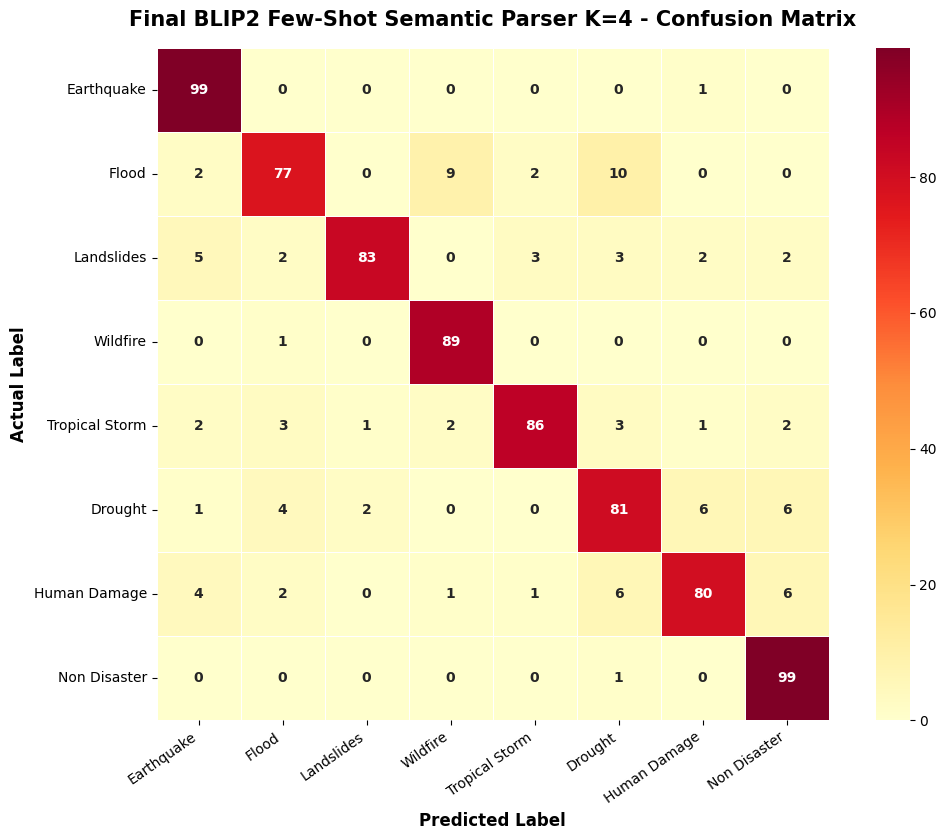


Prediction distribution:
Prediction
Non Disaster      115
Earthquake        113
Drought           104
Wildfire          101
Tropical Storm     92
Human Damage       90
Flood              89
Landslides         86
Name: count, dtype: int64

BLIP2 parsed prediction distribution:
BLIP2_Prediction
Human Damage      160
Landslides        127
Drought           105
Wildfire           97
Flood              88
Non Disaster       82
Tropical Storm     75
Earthquake         56
Name: count, dtype: int64


In [ ]:
blip2_test_df = run_blip2_on_split(test_df, test_semantic_matrix, "test", BEST_BLIP2_CONFIDENCE_THRESHOLD)
blip2_test_df.to_csv(os.path.join(RESULT_DIR, f"final_blip2_fewshot_k{BLIP2_K_SHOTS}_test.csv"), index=False)

valid_blip2_test_df = blip2_test_df[blip2_test_df["Prediction"] != "ERROR"].copy()
blip2_metrics = evaluate_results(valid_blip2_test_df, f"Final BLIP2 Few-Shot Semantic Parser K={BLIP2_K_SHOTS}")

print("\nBLIP2 parsed prediction distribution:")
print(valid_blip2_test_df["BLIP2_Prediction"].value_counts(dropna=False))

## 7. Clear BLIP2 before Qwen

In [ ]:
try:
    del blip_model
    del blip_processor
except Exception:
    pass

torch.cuda.empty_cache()
gc.collect()
print("BLIP2 cleared.")

BLIP2 cleared.


## 8. Qwen2-VL K=4 few-shot

In [ ]:
RUN_QWEN = True
QWEN_K_SHOTS = 4
QWEN_MAX_TEXT_CHARS = 160
QWEN_IMAGE_SIZE = 336
QWEN_CONFIDENCE_THRESHOLD = 0.010

if RUN_QWEN:
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
    from qwen_vl_utils import process_vision_info

    torch.cuda.empty_cache()
    gc.collect()

    QWEN_MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

    qwen_quant = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID, trust_remote_code=True)
    qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        quantization_config=qwen_quant,
        device_map="auto",
        trust_remote_code=True
    )
    qwen_model.eval()

    try:
        qwen_processor.image_processor.max_pixels = QWEN_IMAGE_SIZE * QWEN_IMAGE_SIZE
        qwen_processor.image_processor.min_pixels = 112 * 112
    except Exception:
        pass

    print("Qwen2-VL loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Qwen2-VL loaded.


In [ ]:
def build_qwen_prompt(fewshot_rows, test_context, option_text, label_to_letter):
    examples = []

    for i, (_, row) in enumerate(fewshot_rows.iterrows(), start=1):
        ctx = clean_text(row["context"])[:QWEN_MAX_TEXT_CHARS]
        label = row["category"]
        if label not in label_to_letter:
            continue
        examples.append(f"Example {i}:\nBangla context: {ctx}\nAnswer: {label_to_letter[label]}\n")

    examples_text = "\n".join(examples)
    test_text = clean_text(test_context)[:QWEN_MAX_TEXT_CHARS]

    prompt = f'''
You are a disaster classification expert.

Classify the given image and Bangla context.

Choose one option.

Options:
{option_text}

Few-shot examples:
{examples_text}

Test Bangla context:
{test_text}

Rules:
1. Use both image and Bangla context.
2. If the image is unclear, trust the Bangla context more.
3. Answer only one option letter.
4. Do not explain.

Answer:
'''.strip()

    return prompt[:1600]

def qwen_predict(image_path, test_context, test_vec, sample_id, confidence_threshold):
    semantic_pred, candidates, _, confidence_gap = semantic_predict_with_params(
        text=test_context,
        text_vec=test_vec,
        knn_k=best_params["knn_k"],
        w_knn=best_params["w_knn"],
        w_centroid=best_params["w_centroid"],
        w_keyword=best_params["w_keyword"],
        top_n=TOP_CANDIDATE_CLASSES
    )

    fewshots = get_candidate_fewshots(test_vec, candidates, QWEN_K_SHOTS)
    option_text, letter_to_label, label_to_letter = make_candidate_options(candidates, SEED + int(sample_id))
    prompt_text = build_qwen_prompt(fewshots, test_context, option_text, label_to_letter)

    image = load_and_resize_image(image_path, QWEN_IMAGE_SIZE)
    if image is None:
        return semantic_pred, "IMAGE_LOAD_ERROR", semantic_pred, candidates, option_text, confidence_gap, None

    messages = [{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": prompt_text}]}]

    prompt = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = qwen_processor(text=[prompt], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to("cuda")

    with torch.no_grad():
        generated_ids = qwen_model.generate(**inputs, max_new_tokens=8, do_sample=False)

    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    raw = qwen_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

    qwen_pred = parse_letter_output(raw, letter_to_label)

    if qwen_pred is None:
        final_pred = semantic_pred
    elif qwen_pred not in candidates:
        final_pred = semantic_pred
    elif confidence_gap >= confidence_threshold:
        final_pred = semantic_pred
    else:
        final_pred = qwen_pred

    del inputs, generated_ids, generated_ids_trimmed

    return final_pred, raw, semantic_pred, candidates, option_text, confidence_gap, qwen_pred

In [ ]:
def run_qwen_on_split(df, semantic_matrix, split_name, confidence_threshold):
    results = []

    print(f"Running Qwen on {split_name}: {len(df)} samples")
    print("Confidence threshold:", confidence_threshold)

    for sample_no, (idx, row) in enumerate(tqdm(df.iterrows(), total=len(df))):
        image_path = row["image_path"]
        context = row["context"]
        gt = row["category"]
        test_vec = semantic_matrix[sample_no]

        if not os.path.exists(image_path):
            final_pred, raw, semantic_pred, candidates, options, gap, qwen_pred = "ERROR", "MISSING_IMAGE", "ERROR", [], "", 0.0, None
        else:
            try:
                final_pred, raw, semantic_pred, candidates, options, gap, qwen_pred = qwen_predict(image_path, context, test_vec, sample_no, confidence_threshold)
            except RuntimeError as e:
                print("\nRuntime error on:", row["image_id"])
                print(str(e))
                raise e
            except Exception as e:
                final_pred, raw, semantic_pred, candidates, options, gap, qwen_pred = "ERROR", f"ERROR: {str(e)}", "ERROR", [], "", 0.0, None

        results.append({
            "image_id": row["image_id"],
            "Ground_Truth": gt,
            "Prediction": final_pred,
            "Qwen_Prediction": qwen_pred,
            "Semantic_Prediction": semantic_pred,
            "Candidate_Classes": ", ".join(candidates),
            "Semantic_Gap": gap,
            "Raw_Output": raw,
            "Options": options,
            "Match": final_pred == gt,
            "Context": context,
            "Image_Path": image_path
        })

    return pd.DataFrame(results)

Running Qwen on test: 790 samples
Confidence threshold: 0.01


100%|██████████| 790/790 [18:13<00:00,  1.38s/it]


Final Qwen2-VL Few-Shot Semantic Parser K=4
Total samples    : 790
Accuracy         : 88.23%
Macro Precision  : 88.57%
Macro Recall     : 88.36%
Macro F1         : 88.18%

Classification Report:
                precision    recall  f1-score   support

    Earthquake     0.8761    0.9900    0.9296       100
         Flood     0.8864    0.7800    0.8298       100
    Landslides     0.9651    0.8300    0.8925       100
      Wildfire     0.8900    0.9889    0.9368        90
Tropical Storm     0.9560    0.8700    0.9110       100
       Drought     0.7692    0.8000    0.7843       100
  Human Damage     0.8817    0.8200    0.8497       100
  Non Disaster     0.8609    0.9900    0.9209       100

      accuracy                         0.8823       790
     macro avg     0.8857    0.8836    0.8818       790
  weighted avg     0.8856    0.8823    0.8811       790


Confusion Matrix:


,Earthquake,Flood,Landslides,Wildfire,Tropical Storm,Drought,Human Damage,Non Disaster
Earthquake,99,0,0,0,0,0,1,0
Flood,1,78,0,10,1,10,0,0
Landslides,5,3,83,0,2,3,2,2
Wildfire,1,0,0,89,0,0,0,0
Tropical Storm,2,3,0,0,87,5,1,2
Drought,1,3,3,0,0,80,7,6
Human Damage,4,1,0,1,1,5,82,6
Non Disaster,0,0,0,0,0,1,0,99


Saved colorful confusion matrix: /content/drive/MyDrive/AI_Project/BanglaCalamityMMD/final_few_shot_results/Final_Qwen2-VL_Few-Shot_Semantic_Parser_K=4_confusion_matrix.png


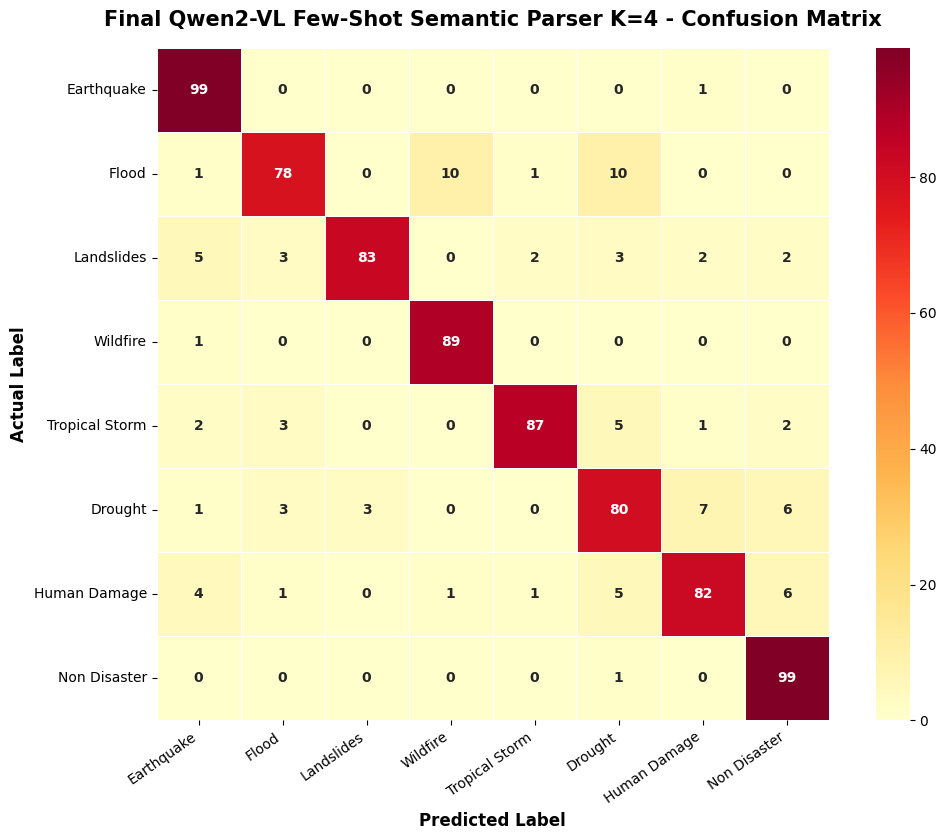


Prediction distribution:
Prediction
Non Disaster      115
Earthquake        113
Drought           104
Wildfire          100
Human Damage       93
Tropical Storm     91
Flood              88
Landslides         86
Name: count, dtype: int64

Qwen parsed prediction distribution:
Qwen_Prediction
Non Disaster      152
Flood             118
Wildfire          114
Earthquake        104
Landslides         93
Human Damage       79
Drought            70
Tropical Storm     60
Name: count, dtype: int64


In [ ]:
qwen_test_df = run_qwen_on_split(test_df, test_semantic_matrix, "test", QWEN_CONFIDENCE_THRESHOLD)
qwen_test_df.to_csv(os.path.join(RESULT_DIR, f"final_qwen_fewshot_k{QWEN_K_SHOTS}_test.csv"), index=False)

valid_qwen_test_df = qwen_test_df[qwen_test_df["Prediction"] != "ERROR"].copy()
qwen_metrics = evaluate_results(valid_qwen_test_df, f"Final Qwen2-VL Few-Shot Semantic Parser K={QWEN_K_SHOTS}")

print("\nQwen parsed prediction distribution:")
print(valid_qwen_test_df["Qwen_Prediction"].value_counts(dropna=False))